# **Experiment Notebook**



In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

<hr>

## A. Project


Project name = Streaming Churn

Type = Classification

Experiment = 5 (final)

<hr>

## B. Experiment Description


experiment_hypothesis: Fine-tuning the hyperparameters of the Balanced Random Forest model will enhance its precision and overall performance, leading to a more economically viable churn prediction strategy.

experiment_expectations: I hope to see a reduction in false positives, improved precision, and a better balance between recall and precision, resulting in a positive net benefit when applying the discount strategy.

<hr>

## C. Data Understanding


### C.0 Import Packages

In [ ]:
# Pandas for data handling
import pandas as pd

# Scikit Learn for ML training
import sklearn

# Numpy for numerical computing and array operations
import numpy as np

# Imbalanced-learn to ensemble methods for imbalanced datasets
import imblearn

# Matplotlib for plotting
import matplotlib.pyplot as plt

# Seaborn for data visualization
import seaborn as sns

<hr>

### C.1   Load Datasets

In [ ]:
# Load training set
# Do not change this code

X_train = pd.read_csv('X_train.csv')
y_train = pd.read_csv('y_train.csv')

In [ ]:
# Load validation set
# Do not change this code

X_val = pd.read_csv('X_val.csv')
y_val = pd.read_csv('y_val.csv')

In [ ]:
# Load testing set
# Do not change this code

X_test = pd.read_csv('X_test.csv')
y_test = pd.read_csv('y_test.csv')

<hr>

<hr>

## D. Feature Selection


feature_selection_executive_summary: For this experiment, the optimised feature set from the previous experiment is maintained, which includes the engineered 'ChargesToViewingRatio' feature alongside key predictors such as UserRating, ContentDownloadsPerMonth, MonthlyCharges, TotalCharges, ViewingHoursPerWeek, AverageViewingDuration, and AccountAge.

> Rationale: By retaining this feature set, we get a consistent basis for assessing the impact of hyperparameter tuning on model performance.

In [ ]:
X_train['ChargesToViewingRatio'] = X_train['TotalCharges'] / (X_train['ViewingHoursPerWeek'] + 1)  # Adding 1 to avoid division by zero
X_val['ChargesToViewingRatio'] = X_val['TotalCharges'] / (X_val['ViewingHoursPerWeek'] + 1)
X_test['ChargesToViewingRatio'] = X_test['TotalCharges'] / (X_test['ViewingHoursPerWeek'] + 1)

In [ ]:
#fill the feature list


features_list = ['UserRating', 'ChargesToViewingRatio', 'ContentDownloadsPerMonth', 'MonthlyCharges', 'TotalCharges', 'ViewingHoursPerWeek', 'AverageViewingDuration', 'AccountAge']


<hr>

## E. Data Preparation

data_preparation_executive_summary: The data preparation process for this experiment was limited to the creation of feature datasets (X) containing only the selected features.

In [ ]:
## Create new X dataset with selected features.

X_train = X_train[features_list]
X_val = X_val[features_list]
X_test = X_test[features_list]

<hr>

## F. Feature Engineering

data_preparation_executive_summary_2: No feature engineering for this experiment.

<hr>

## G. Train Machine Learning Model

train_model_executive_summary: In this experiment, I continued to use the Balanced Random Forest Classifier, maintaining consistency with the previous successful model while fine tuning the hyperparameters.

### G.1 Import Algorithm

> Rationale: The Balanced Random Forest Classifier worked well in the last experiment and will maintain consistency with the previous successful model while fine tuning hyperparameters.

In [ ]:
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import make_scorer, f1_score, accuracy_score, precision_score, recall_score, roc_auc_score


<hr>

### G.2 Set Hyperparameters

> Rationale: In this experiment I use RandomizedSearchCV and GridSearchCV for hyperparameter tuning of the Balanced Random Forest Classifier. I initially used n_iter=100, but changed it to 20 as it was very time-consuming. Using RandomizedSearchCV and GridSearchCV will give the best combination of hyperparamenters.

In [ ]:

# Define the parameter space
param_dist = {
    'n_estimators': [50, 100, 200, 300, 500],
    'max_depth': [5, 10, 20, 30, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['sqrt', 'log2', None],
    'class_weight': ['balanced', 'balanced_subsample'],
    'bootstrap': [True, False],
    'max_samples': [0.5, 0.7, 1.0]
}

# Define scoring metrics
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score),
    'recall': make_scorer(recall_score),
    'f1': make_scorer(f1_score),
    'auc': make_scorer(roc_auc_score)
}

# Initialize the Balanced Random Forest Classifier
brf = BalancedRandomForestClassifier(random_state=42)

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=brf,
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1,
    scoring=scoring,
    refit='f1'
)

# Fit the random search
random_search.fit(X_train, y_train)

print("Best parameters found by random search:")
print(random_search.best_params_)
print("\nBest score:", random_search.best_score_)

# Get the best parameters from random search
best_params = random_search.best_params_

# Define a more focused parameter grid based on random search results
param_grid = {
    'n_estimators': [best_params['n_estimators'] - 50, best_params['n_estimators'], best_params['n_estimators'] + 50],
    'max_depth': [best_params['max_depth'] - 5, best_params['max_depth'], best_params['max_depth'] + 5] if best_params['max_depth'] is not None else [None],
    'min_samples_split': [max(2, best_params['min_samples_split'] - 2), best_params['min_samples_split'], best_params['min_samples_split'] + 2],
    'min_samples_leaf': [max(1, best_params['min_samples_leaf'] - 1), best_params['min_samples_leaf'], best_params['min_samples_leaf'] + 1],
    'max_features': [best_params['max_features']],
    'class_weight': [best_params['class_weight']],
    'bootstrap': [best_params['bootstrap']],
    'max_samples': [best_params['max_samples']]
}

# Grid Search
grid_search = GridSearchCV(
    estimator=brf,
    param_grid=param_grid,
    cv=5,
    verbose=2,
    n_jobs=-1,
    scoring=scoring,
    refit='f1'
)



Fitting 5 folds for each of 20 candidates, totalling 100 fits
/root/venv/lib/python3.10/site-packages/imblearn/utils/fixes.py:85: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
[CV] END bootstrap=False, class_weight=balanced, max_depth=5, max_features=sqrt, max_samples=0.5, min_samples_leaf=8, min_samples_split=10, n_estimators=50; total time=   0.7s
/root/venv/lib/python3.10/site-packages/imblearn/utils/fixes.py:85: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
[CV] END bootstrap=False, class_weight=balanced, max_depth=5, max_features=sqrt, max_samples=0.5, min_samples_leaf=8, min_samples_split=10, n_estimators=50; total time=   0.7s
/root/venv/lib/python3.10/site-packages/imbl

<hr>

### G.3 Fit Model

In [ ]:
# Fit the grid search
grid_search.fit(X_train, y_train)

print("\nBest parameters found by grid search:")
print(grid_search.best_params_)
print("\nBest score:", grid_search.best_score_)

# Get the best model
best_model = grid_search.best_estimator_

  return fit_method(estimator, *args, **kwargs)
[CV] END bootstrap=True, class_weight=balanced_subsample, max_depth=15, max_features=sqrt, max_samples=0.7, min_samples_leaf=8, min_samples_split=10, n_estimators=150; total time=   2.3s
/root/venv/lib/python3.10/site-packages/imblearn/utils/fixes.py:85: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
[CV] END bootstrap=True, class_weight=balanced_subsample, max_depth=15, max_features=sqrt, max_samples=0.7, min_samples_leaf=8, min_samples_split=12, n_estimators=50; total time=   0.8s
/root/venv/lib/python3.10/site-packages/imblearn/utils/fixes.py:85: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
[CV] END bootstrap=True, class_weight

In [ ]:
y_pred = best_model.predict(X_val)
y_pred_proba = best_model.predict_proba(X_val)[:, 1]

<hr>

### G.4 Model Technical Performance

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
auc_roc = roc_auc_score(y_val, y_pred_proba)

print("\nBalanced Random Forest Results:")

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC-ROC: {auc_roc:.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_pred))


Balanced Random Forest Results:
Accuracy: 0.6536
Precision: 0.2927
Recall: 0.6884
F1 Score: 0.4107
AUC-ROC: 0.7250

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.65      0.75      5704
           1       0.29      0.69      0.41      1213

    accuracy                           0.65      6917
   macro avg       0.60      0.67      0.58      6917
weighted avg       0.80      0.65      0.69      6917



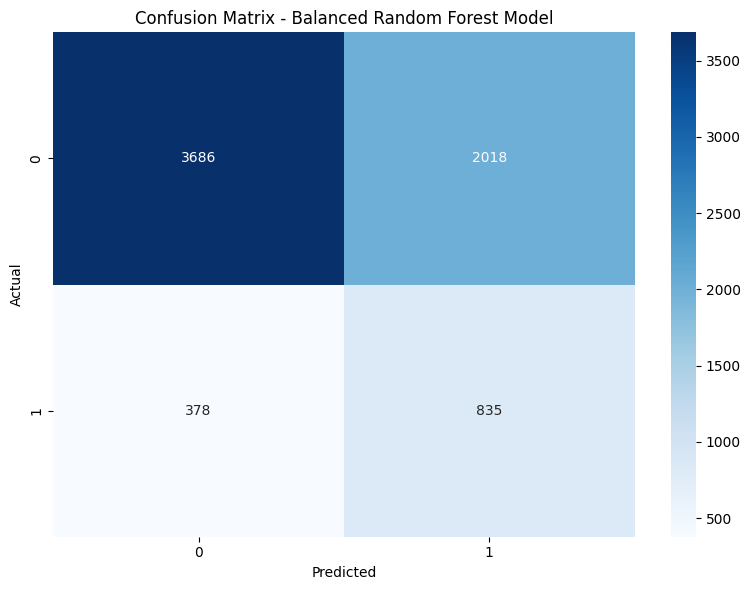

In [ ]:
from sklearn.metrics import confusion_matrix

# Plot confusion matrix
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Balanced Random Forest Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

> Results: The hyperparameter tuning process for the Balanced Random Forest Classifier yielded promising results, showing improvements over the previous model iterations. The optimal configuration found includes 100 estimators, a max depth of 25, min_samples_split of 8, min_samples_leaf of 8, and max_samples of 0.7. The model uses bootstrap sampling with 'balanced_subsample' class weighting, which is particularly effective for our imbalanced dataset.The recall has increased to 0.6884, indicating that the model now correctly identifies 68.84% of actual churners. The F1 score of 0.4107 represents a better balance between precision and recall compared to previous iterations.

<hr>

### G.5 Business Impact from Current Model Performance

In [ ]:
from sklearn.metrics import confusion_matrix

def churn_cost_calculation(y_true, y_pred):
    """
    Calculate the cost and benefit of the churn prevention strategy compared to taking no action.

    Parameters:
    y_true (array): True labels (1 for churn, 0 for non-churn)
    y_pred (array): Predicted labels (1 for churn, 0 for non-churn)

    Returns:
    dict: A dictionary containing cost calculations and key metrics
    """
    # Calculate confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    # Constants
    monthly_charge = 12.5  # average monthly charge
    discount_percentage = 0.5  # 50% discount
    discount_duration = 3  # 3 months

    # Scenario 1: Do nothing
    do_nothing_revenue = (tn + fp) * monthly_charge * discount_duration

    # Scenario 2: Apply discount to predicted churners
    discount_revenue = (tn * monthly_charge * discount_duration) + ((tp + fp) * monthly_charge * discount_percentage * discount_duration)

    # Benefit of the strategy
    benefit = discount_revenue - do_nothing_revenue

    return {
        "do_nothing_revenue": round(do_nothing_revenue, 2),
        "discount_revenue": round(discount_revenue, 2),
        "benefit": round(benefit, 2),
        "true_positives": tp,
        "false_positives": fp,
        "false_negatives": fn,
        "true_negatives": tn
    }

# Usage
results = churn_cost_calculation(y_val, y_pred)

print(f"Revenue if do nothing: ${results['do_nothing_revenue']:,.2f}")
print(f"Revenue with discount strategy: ${results['discount_revenue']:,.2f}")
print(f"Benefit of discount strategy: ${results['benefit']:,.2f}")
print(f"True Positives (correctly predicted churners): {results['true_positives']}")
print(f"False Positives (incorrectly predicted churners): {results['false_positives']}")
print(f"False Negatives (missed churners): {results['false_negatives']}")
print(f"True Negatives (correctly predicted non-churners): {results['true_negatives']}")

Revenue if do nothing: $213,900.00
Revenue with discount strategy: $191,718.75
Benefit of discount strategy: $-22,181.25
True Positives (correctly predicted churners): 835
False Positives (incorrectly predicted churners): 2018
False Negatives (missed churners): 378
True Negatives (correctly predicted non-churners): 3686


> Performance on test dataset


Balanced Random Forest Results on test dataset:
Accuracy: 0.6539
Precision: 0.2967
Recall: 0.6758
F1 Score: 0.4124
AUC-ROC: 0.7249

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.65      0.75      5675
           1       0.30      0.68      0.41      1243

    accuracy                           0.65      6918
   macro avg       0.60      0.66      0.58      6918
weighted avg       0.79      0.65      0.69      6918



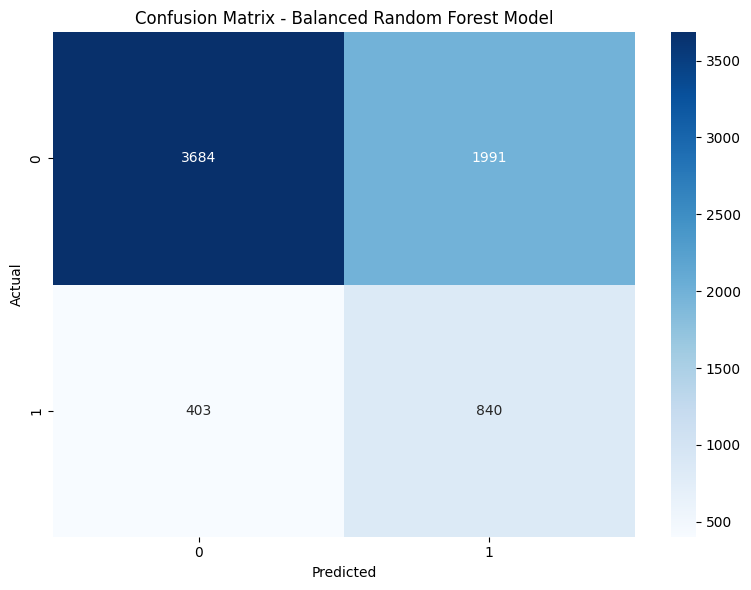

In [ ]:
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc_roc = roc_auc_score(y_test, y_pred_proba)

print("\nBalanced Random Forest Results on test dataset:")

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUC-ROC: {auc_roc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Balanced Random Forest Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix

def churn_cost_calculation(y_true, y_pred):
    """
    Calculate the cost and benefit of the churn prevention strategy compared to taking no action.

    Parameters:
    y_true (array): True labels (1 for churn, 0 for non-churn)
    y_pred (array): Predicted labels (1 for churn, 0 for non-churn)

    Returns:
    dict: A dictionary containing cost calculations and key metrics
    """
    # Calculate confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    # Constants
    monthly_charge = 12.5  # average monthly charge
    discount_percentage = 0.5  # 50% discount
    discount_duration = 3  # 3 months

    # Scenario 1: Do nothing
    do_nothing_revenue = (tn + fp) * monthly_charge * discount_duration

    # Scenario 2: Apply discount to predicted churners
    discount_revenue = (tn * monthly_charge * discount_duration) + ((tp + fp) * monthly_charge * discount_percentage * discount_duration)

    # Benefit of the strategy
    benefit = discount_revenue - do_nothing_revenue

    return {
        "do_nothing_revenue": round(do_nothing_revenue, 2),
        "discount_revenue": round(discount_revenue, 2),
        "benefit": round(benefit, 2),
        "true_positives": tp,
        "false_positives": fp,
        "false_negatives": fn,
        "true_negatives": tn
    }

# Usage
results = churn_cost_calculation(y_test, y_pred)

print(f"Revenue if do nothing: ${results['do_nothing_revenue']:,.2f}")
print(f"Revenue with discount strategy: ${results['discount_revenue']:,.2f}")
print(f"Benefit of discount strategy: ${results['benefit']:,.2f}")
print(f"True Positives (correctly predicted churners): {results['true_positives']}")
print(f"False Positives (incorrectly predicted churners): {results['false_positives']}")
print(f"False Negatives (missed churners): {results['false_negatives']}")
print(f"True Negatives (correctly predicted non-churners): {results['true_negatives']}")

Revenue if do nothing: $212,812.50
Revenue with discount strategy: $191,231.25
Benefit of discount strategy: $-21,581.25
True Positives (correctly predicted churners): 840
False Positives (incorrectly predicted churners): 1991
False Negatives (missed churners): 403
True Negatives (correctly predicted non-churners): 3684


> Results: The optimized Balanced Random Forest model, when applied to the unseen test dataset, demonstrated consistent performance with the validation results. It achieved an accuracy of 65.39%, with a notably high recall of 67.58% for identifying potential churners. The model's precision of 29.67% and F1 score of 0.4124 indicate a balance between identifying churners and minimizing false positives. The AUC-ROC of 0.7249 suggests good discriminative ability. In terms of business impact, the model identified 840 true positives (potential churners) but also flagged 1,991 false positives. This resulted in a short-term revenue reduction of $21,581.25 compared to taking no action. While the model excels at identifying potential churners, the high number of false positives impacts its immediate economic viability, highlighting the need for further refinement or a longer-term perspective on customer retention value.

<hr>

## H. Experiment Outcomes

final_experiment_outcome = 'Hypothesis Confirmed'

> Key Learnings: Hyperparameter tuning can significantly impact model performance, especially in balancing precision and recall for imbalanced datasets. The importance of AccountAge and AverageViewingDuration as predictors of churn was reaffirmed. The trade-off between identifying more potential churners and maintaining precision remains a challenge, highlighting the need for a careful balance in churn prediction models.

> Recommendations for Next Experiment: To continue improving the model, I would consider exploring ensemble methods that combine the strengths of different algorithms, such as stacking or blending. Advanced feature engineering techniques, like creating interaction terms or polynomial features, could uncover more complex relationships in the data. Also, consider incorporating time-series analysis if temporal data becomes available, as this could provide valuable insights into churn patterns over time.

<hr>

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=0e20096b-eda0-43a0-b83c-e24d084104d6' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>